In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import ExtraTreeClassifier
from sklearn.svm import SVC
import xgboost as xgb
from sklearn.metrics import f1_score 
from sklearn.metrics import classification_report , confusion_matrix
import warnings
import pickle




In [3]:
df = pd.read_csv("D:\scam_fraud_detection\scram_data.csv")

In [4]:
df.head(10)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.0,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.0,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.0,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.0,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.0,0.00,0,0
5,1,PAYMENT,7817.71,C90045638,53860.00,46042.29,M573487274,0.0,0.00,0,0
6,1,PAYMENT,7107.77,C154988899,183195.00,176087.23,M408069119,0.0,0.00,0,0
7,1,PAYMENT,7861.64,C1912850431,176087.23,168225.59,M633326333,0.0,0.00,0,0
8,1,PAYMENT,4024.36,C1265012928,2671.00,0.00,M1176932104,0.0,0.00,0,0
9,1,DEBIT,5337.77,C712410124,41720.00,36382.23,C195600860,41898.0,40348.79,0,0


In [8]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [10]:
df.drop(['isFlaggedFraud'],axis=1,inplace=True)

In [11]:
df

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0
...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1


In [12]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0


In [13]:
df.tail()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.0,C776919290,0.00,339682.13,1
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.0,C1881841831,0.00,0.00,1
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.0,C1365125890,68488.84,6379898.11,1
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.0,C2080388513,0.00,0.00,1
6362619,743,CASH_OUT,850002.52,C1280323807,850002.52,0.0,C873221189,6510099.11,7360101.63,1


In [15]:
plt.style.use('ggplot')
warnings.filterwarnings('ignore')

In [19]:
df.corr(numeric_only=True)

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
step,1.000000,0.022373,-0.010058,-0.010299,0.027665,0.025888,0.031578
amount,0.022373,1.000000,-0.002762,-0.007861,0.294137,0.459304,0.076688
oldbalanceOrg,-0.010058,-0.002762,1.000000,0.998803,0.066243,0.042029,0.010154
newbalanceOrig,-0.010299,-0.007861,0.998803,1.000000,0.067812,0.041837,-0.008148
oldbalanceDest,0.027665,0.294137,0.066243,0.067812,1.000000,0.976569,-0.005885
newbalanceDest,0.025888,0.459304,0.042029,0.041837,0.976569,1.000000,0.000535
isFraud,0.031578,0.076688,0.010154,-0.008148,-0.005885,0.000535,1.000000


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 10 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
dtypes: float64(5), int64(2), object(3)
memory usage: 485.4+ MB


<Axes: >

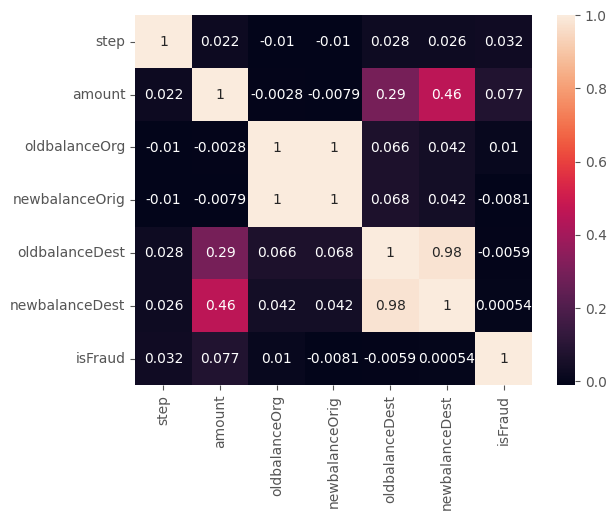

In [21]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

<Axes: xlabel='step', ylabel='Count'>

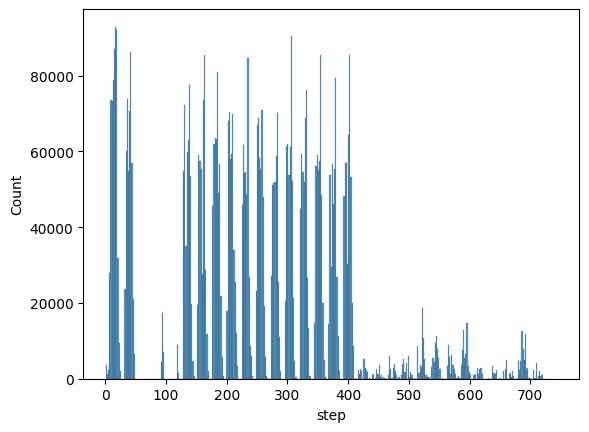

In [5]:
sns.histplot(data=df,x='step')

<Axes: xlabel='step'>

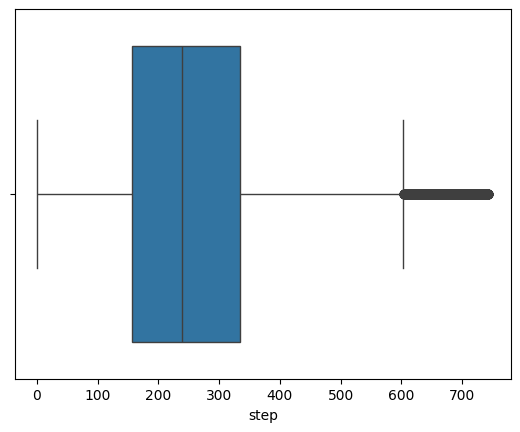

In [6]:
sns.boxplot(data=df,x ='step')

<Axes: xlabel='type', ylabel='count'>

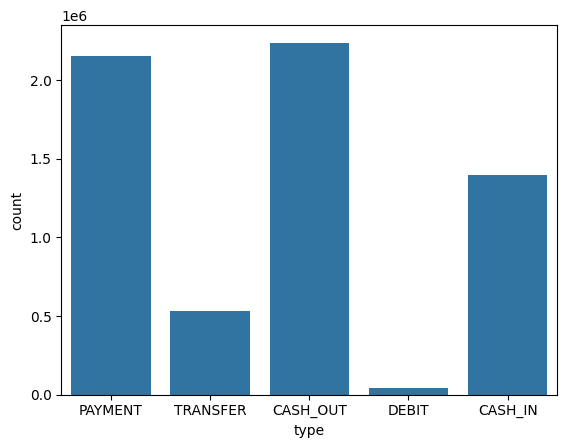

In [7]:
sns.countplot(data=df,x='type')

<Axes: xlabel='amount', ylabel='Count'>

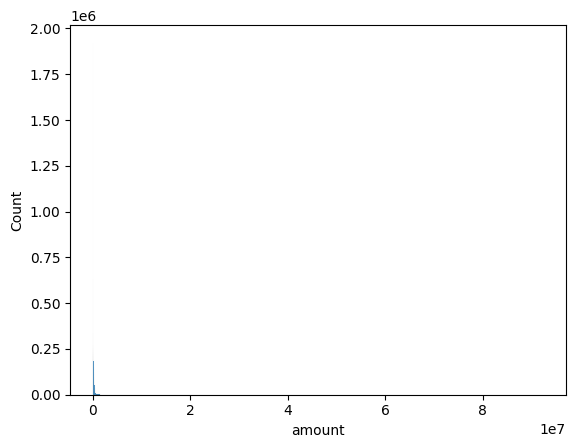

In [8]:
sns.histplot(data=df,x='amount')

<Axes: xlabel='amount'>

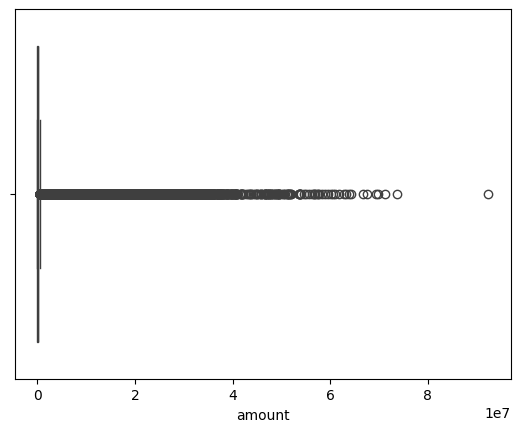

In [12]:
sns.boxplot(data=df,x='amount')

<Axes: xlabel='oldbalanceOrg', ylabel='Count'>

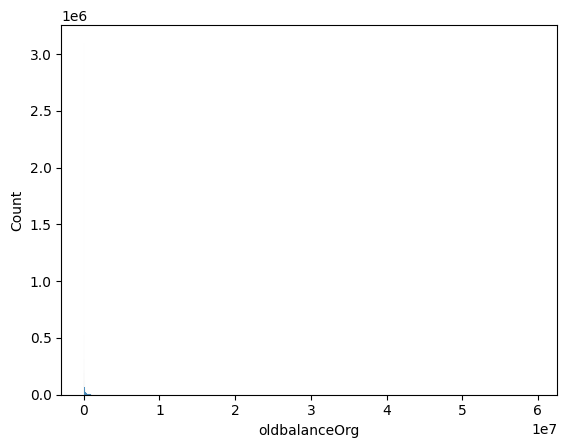

In [13]:
sns.histplot(data=df,x='oldbalanceOrg')

In [15]:
df['nameDest'].value_counts()

nameDest
C1286084959    113
C985934102     109
C665576141     105
C2083562754    102
C248609774     101
              ... 
C1049862186      1
C2118381511      1
C2099952089      1
C1027984317      1
C1251365829      1
Name: count, Length: 2722362, dtype: int64

<Axes: xlabel='oldbalanceOrg'>

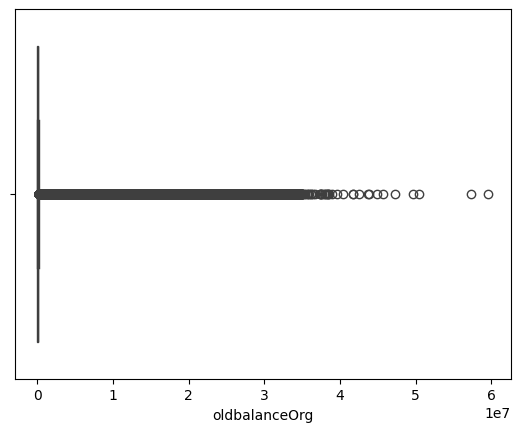

In [16]:
sns.boxplot(data=df,x='oldbalanceOrg')

<Axes: xlabel='newbalanceDest'>

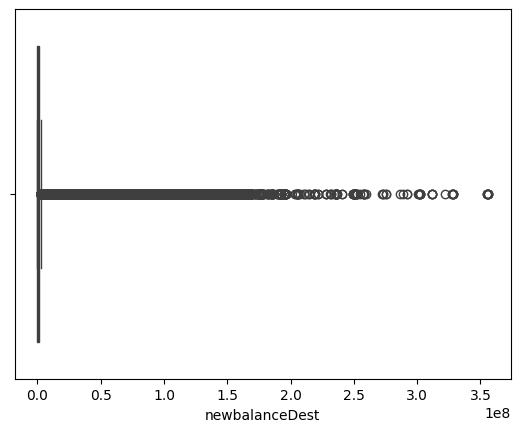

In [17]:
sns.boxplot(data=df,x='newbalanceDest')

<Axes: xlabel='isFraud', ylabel='count'>

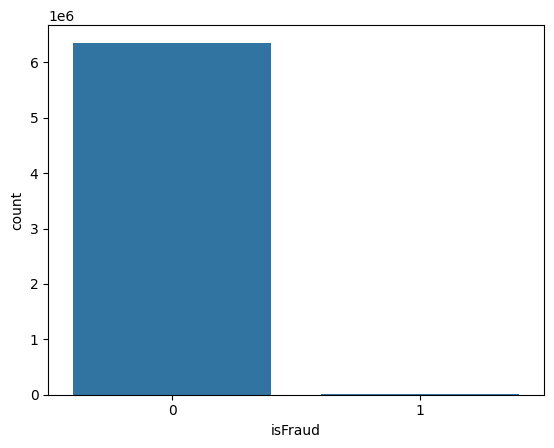

In [19]:
sns.countplot(data=df,x='isFraud')

In [6]:
df['isFraud'].value_counts()

isFraud
is_not_Fraud    6354407
is_Fraud           8213
Name: count, dtype: int64

In [7]:
df.loc[df['isFraud']==1,'isFraud'] ='is_Fraud'
df.loc[df['isFraud']==0,'isFraud'] = 'is_not_Fraud'

In [7]:
df

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,is_not_Fraud,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,is_not_Fraud,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,is_Fraud,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,is_Fraud,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,is_not_Fraud,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,is_Fraud,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,is_Fraud,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,is_Fraud,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,is_Fraud,0


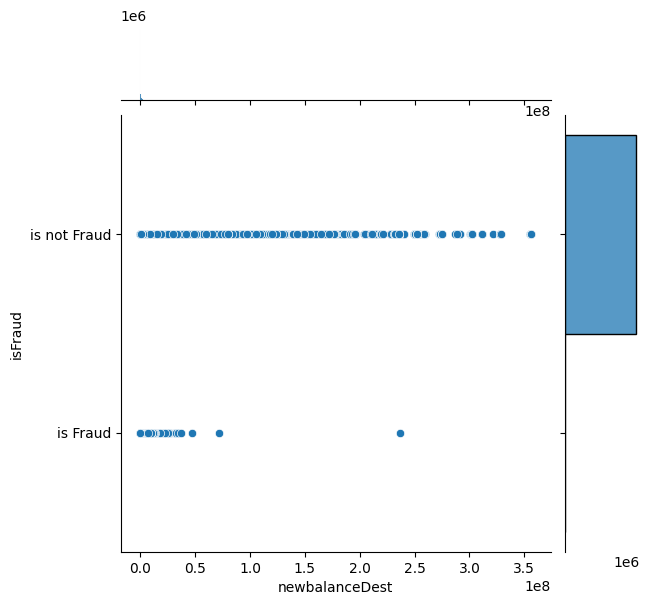

In [27]:
sns.jointplot(data=df,x='newbalanceDest',y='isFraud')

<Axes: xlabel='type', ylabel='count'>

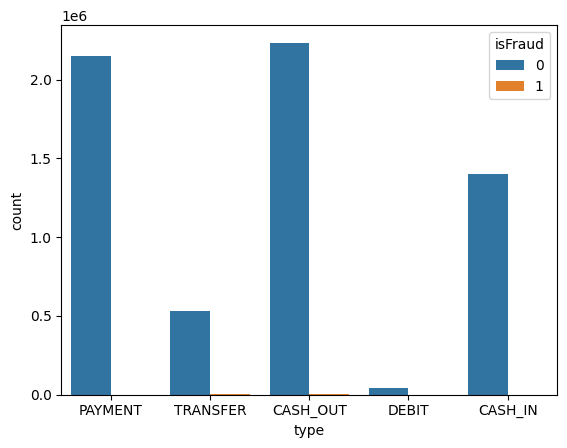

In [5]:
sns.countplot(data=df,x='type',hue='isFraud')

<Axes: xlabel='step'>

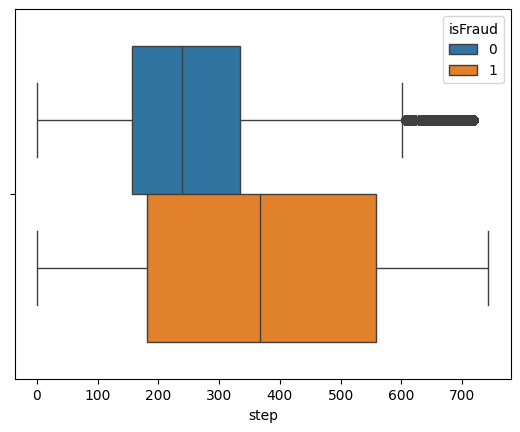

In [7]:
sns.boxplot(data=df,x='step',hue='isFraud')

<Axes: xlabel='isFraud', ylabel='amount'>

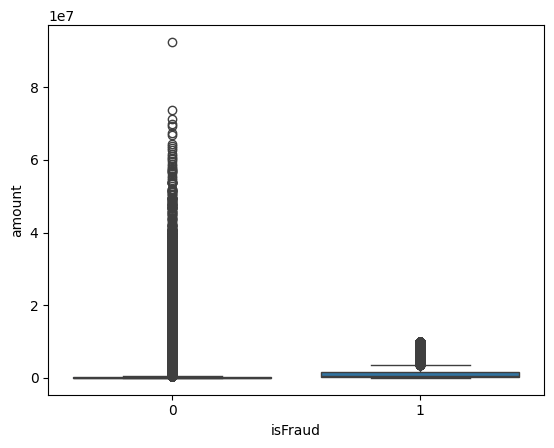

In [10]:
sns.boxplot(data=df,x='isFraud', y='amount')

<Axes: xlabel='isFraud', ylabel='oldbalanceOrg'>

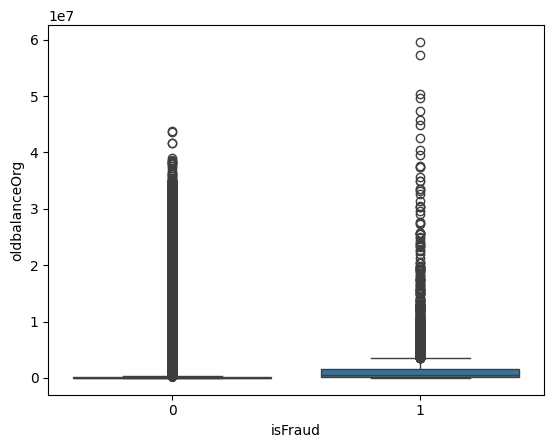

In [5]:
sns.boxplot(data=df,x='isFraud',y='oldbalanceOrg')

<Axes: xlabel='isFraud', ylabel='newbalanceOrig'>

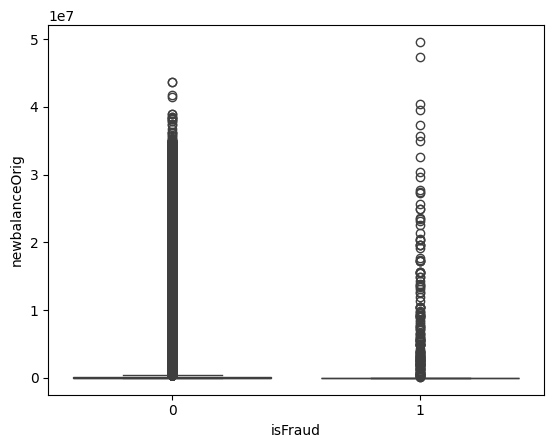

In [6]:
sns.boxplot(data=df,x='isFraud',y='newbalanceOrig')

<Axes: xlabel='isFraud', ylabel='oldbalanceDest'>

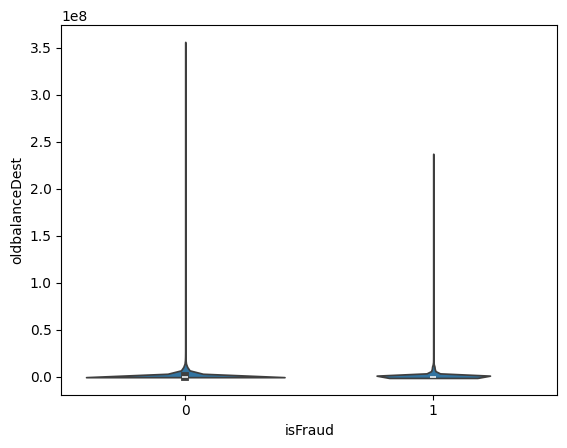

In [9]:
sns.violinplot(data=df,x='isFraud',y='oldbalanceDest')

<Axes: xlabel='isFraud', ylabel='newbalanceDest'>

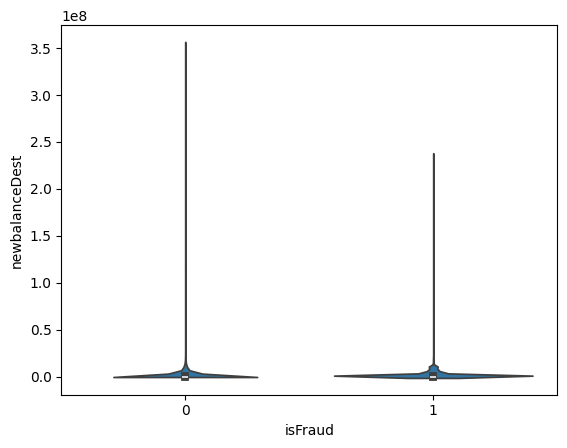

In [10]:
sns.violinplot(data=df,x='isFraud',y='newbalanceDest')

In [11]:
df.describe(include='all')

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6362620,6.362620e+06,6362620,6.362620e+06,6.362620e+06,6362620,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
unique,NaN,5,NaN,6353307,NaN,NaN,2722362,NaN,NaN,NaN,NaN
top,NaN,CASH_OUT,NaN,C1677795071,NaN,NaN,C1286084959,NaN,NaN,NaN,NaN
freq,NaN,2237500,NaN,3,NaN,NaN,113,NaN,NaN,NaN,NaN
mean,2.433972e+02,NaN,1.798619e+05,NaN,8.338831e+05,8.551137e+05,NaN,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,NaN,6.038582e+05,NaN,2.888243e+06,2.924049e+06,NaN,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,NaN,0.000000e+00,NaN,0.000000e+00,0.000000e+00,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,NaN,1.338957e+04,NaN,0.000000e+00,0.000000e+00,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,NaN,7.487194e+04,NaN,1.420800e+04,0.000000e+00,NaN,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,NaN,2.087215e+05,NaN,1.073152e+05,1.442584e+05,NaN,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00


In [13]:
df.shape

(6362620, 11)

In [8]:
df.drop(['nameOrig','nameDest'],axis=1,inplace=True)
df.columns

Index(['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
       'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud'],
      dtype='object')

In [5]:
df.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,0
1,1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,0
2,1,TRANSFER,181.00,181.0,0.00,0.0,0.0,1,0
3,1,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0,0


In [6]:
df.isnull().sum()

step              0
type              0
amount            0
oldbalanceOrg     0
newbalanceOrig    0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 9 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   oldbalanceOrg   float64
 4   newbalanceOrig  float64
 5   oldbalanceDest  float64
 6   newbalanceDest  float64
 7   isFraud         int64  
 8   isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(1)
memory usage: 436.9+ MB


<Axes: xlabel='amount'>

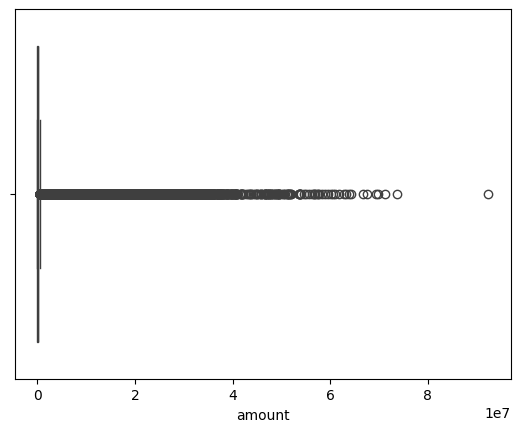

In [21]:
sns.boxplot(x=df['amount'])

In [9]:
from scipy import stats
print(stats.mode(df['amount']))
print(np.mean(df['amount']))

ModeResult(mode=np.float64(10000000.0), count=np.int64(3207))
179861.90354913071


In [10]:
df['amount'].median()

74871.94

In [11]:
q1 = np.quantile(df['amount'],0.25)
q3 = np.quantile(df['amount'],0.75)

IQR = q3-q1

upper_bound=q3+(1.5*IQR)
lower_bound=q1-(1.5*IQR)

print('q1',q1)
print('q3',q3)
print('IQR',IQR)
print('upper_bound',upper_bound)
print('lower_bound',lower_bound)
print('skwed_data',len(df[df['amount']>upper_bound]))
print('skwed_data2',len(df[df['amount']<lower_bound]))

q1 13389.57
q3 208721.4775
IQR 195331.9075
upper_bound 501719.33875
lower_bound -279608.29125
skwed_data 338078
skwed_data2 0


In [12]:
def transformationPlot(feature):
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    sns.histplot(feature, kde=True)    
    plt.subplot(1,2,2)
    stats.probplot(feature,plot=plt)

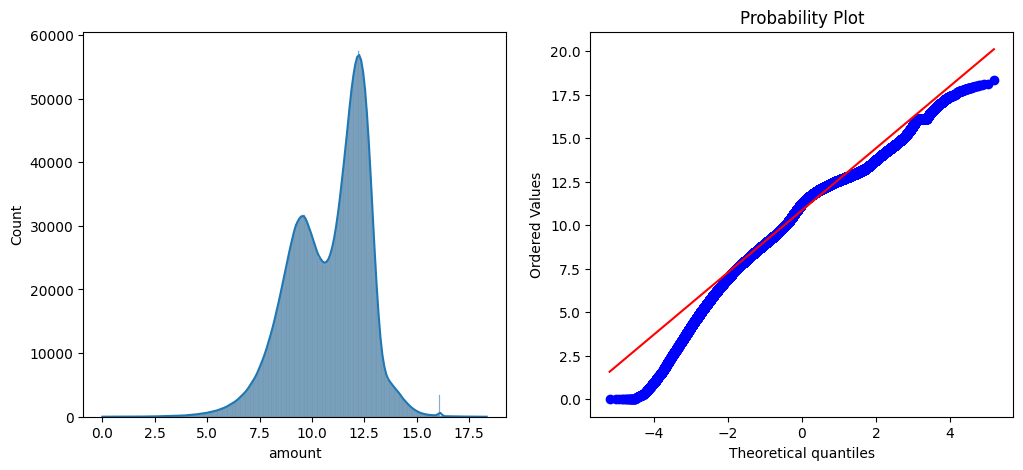

In [6]:
transformationPlot(np.log1p(df['amount']))

In [13]:
df['amount']= np.log1p(df['amount'])

In [14]:
la = LabelEncoder()
df['type']=la.fit_transform(df['type'])

In [15]:
df['type'].value_counts()

type
1    2237500
3    2151495
0    1399284
4     532909
2      41432
Name: count, dtype: int64

In [16]:
x = df.drop('isFraud',axis=1)
y = df['isFraud']

In [17]:
x

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFlaggedFraud
0,1,3,9.194276,170136.00,160296.36,0.00,0.00,0
1,1,3,7.531166,21249.00,19384.72,0.00,0.00,0
2,1,4,5.204007,181.00,0.00,0.00,0.00,0
3,1,1,5.204007,181.00,0.00,21182.00,0.00,0
4,1,3,9.364703,41554.00,29885.86,0.00,0.00,0
...,...,...,...,...,...,...,...,...
6362615,743,1,12.735768,339682.13,0.00,0.00,339682.13,0
6362616,743,4,15.657870,6311409.28,0.00,0.00,0.00,0
6362617,743,1,15.657870,6311409.28,0.00,68488.84,6379898.11,0
6362618,743,4,13.652996,850002.52,0.00,0.00,0.00,0


In [18]:
y

0          is_not_Fraud
1          is_not_Fraud
2              is_Fraud
3              is_Fraud
4          is_not_Fraud
               ...     
6362615        is_Fraud
6362616        is_Fraud
6362617        is_Fraud
6362618        is_Fraud
6362619        is_Fraud
Name: isFraud, Length: 6362620, dtype: object

In [19]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=0,test_size=0.2)


In [20]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(5090096, 8)
(1272524, 8)
(5090096,)
(1272524,)


In [74]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rfc = RandomForestClassifier(
    n_estimators=20,     # reduce number of trees
    max_depth=10,        # limit tree complexity
    n_jobs=-1,           # use all CPU cores
    random_state=0
)

rfc.fit(x_train, y_train)

y_test_predict1 = rfc.predict(x_test)

test_accuracy = accuracy_score(y_test, y_test_predict1)
test_accuracy

0.9996196535389509

In [75]:
y_train_predict1 = rfc.predict(x_train)

test_accuracy = accuracy_score(y_train,y_train_predict1)
test_accuracy

0.999616117259871

In [22]:
pd.crosstab(y_test,y_test_predict1)

col_0,0,1
isFraud,,
0,1270878,5
1,479,1162


In [23]:
print(classification_report(y_test, y_test_predict1))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270883
           1       1.00      0.71      0.83      1641

    accuracy                           1.00   1272524
   macro avg       1.00      0.85      0.91   1272524
weighted avg       1.00      1.00      1.00   1272524



In [77]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score , classification_report

dtc=DecisionTreeClassifier(
    max_depth = 10,
    min_samples_split = 10,
    min_samples_leaf = 5,
    random_state = 0 
)

dtc.fit(x_train,y_train)

y_test_predict2 = dtc.predict(x_test)

test_accuracy = accuracy_score(y_test,y_test_predict2)
test_accuracy

0.9996298694562932

In [78]:
y_train_predict2= dtc.predict(x_train)

test_accuracy = accuracy_score(y_train,y_train_predict2)
test_accuracy

0.9996243685777243

In [31]:
pd.crosstab(y_test,y_test_predict2)

col_0,0,1
isFraud,,
0,1270873,10
1,461,1180


In [32]:
print(classification_report(y_test,y_test_predict2))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270883
           1       0.99      0.72      0.83      1641

    accuracy                           1.00   1272524
   macro avg       1.00      0.86      0.92   1272524
weighted avg       1.00      1.00      1.00   1272524



In [79]:
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import accuracy_score, classification_report

etc = ExtraTreesClassifier(
    n_estimators=100,          # number of trees
    max_depth=10,              # control tree depth
    min_samples_split=10,      # avoid small splits
    min_samples_leaf=5,        # avoid noise
    random_state=0
)

etc.fit(x_train, y_train)

y_test_predict3 = etc.predict(x_test)
test_accuracy =  accuracy_score(y_test, y_test_predict3)
test_accuracy

0.9988102385495283

In [80]:
y_train_predict3 = etc.predict(x_train)
test_accuracy = accuracy_score(y_train,y_train_predict3)
test_accuracy

0.9988096491696816

In [23]:
pd.crosstab(y_test,y_test_predict3)

col_0,0,1
isFraud,,
0,1270882,1
1,1513,128


In [24]:
print(classification_report(y_test,y_test_predict3))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270883
           1       0.99      0.08      0.14      1641

    accuracy                           1.00   1272524
   macro avg       1.00      0.54      0.57   1272524
weighted avg       1.00      1.00      1.00   1272524



In [81]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [82]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

svc = LinearSVC(class_weight='balanced', random_state=0)

svc.fit(x_train_scaled, y_train)

y_test_predict4 = svc.predict(x_test_scaled)
test_accuracy = accuracy_score(y_test,y_test_predict4)
test_accuracy

0.9701671638413106

In [83]:
y_train_predict4 = svc.predict(x_train_scaled)
train_accuracy = accuracy_score(y_train,y_train_predict4)
train_accuracy

0.970097617019404

In [22]:
pd.crosstab(y_test,y_test_predict4)

col_0,0,1
isFraud,,
0,1233156,37727
1,235,1406


In [23]:
print(classification_report(y_test,y_test_predict4))

              precision    recall  f1-score   support

           0       1.00      0.97      0.98   1270883
           1       0.04      0.86      0.07      1641

    accuracy                           0.97   1272524
   macro avg       0.52      0.91      0.53   1272524
weighted avg       1.00      0.97      0.98   1272524



In [24]:
df.columns

Index(['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
       'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud'],
      dtype='object')

In [22]:
df.drop('isFlaggedFraud',axis=1,inplace=True)

In [23]:
la = LabelEncoder()
y_train1=la.fit_transform(y_train)

In [24]:
y_test1 = la.transform(y_test)

In [25]:
y_test1

array([1, 1, 1, ..., 1, 1, 1], shape=(1272524,))

In [26]:
y_train1

array([1, 1, 1, ..., 1, 1, 1], shape=(5090096,))

In [68]:
import xgboost as xgb

xgb1 = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=40,
    random_state=0,
    n_jobs=-1
)

xgb1=xgb1.fit(x_train,y_train1)

y_test_predict5=xgb1.predict(x_test)
test_accuracy=accuracy_score(y_test1,y_test_predict5)
test_accuracy

0.9996974516787109

In [69]:
y_train_predict5=xgb1.predict(x_train)
train_accuracy=accuracy_score(y_train1,y_train_predict5)
train_accuracy

0.9997502994049621

In [70]:
pd.crosstab(y_test1,y_test_predict5)

col_0,0,1
row_0,,
0,1267,374
1,11,1270872


In [71]:
print(classification_report(y_test1,y_test_predict5))

              precision    recall  f1-score   support

           0       0.99      0.77      0.87      1641
           1       1.00      1.00      1.00   1270883

    accuracy                           1.00   1272524
   macro avg       1.00      0.89      0.93   1272524
weighted avg       1.00      1.00      1.00   1272524



In [43]:
print(la.classes_)

['is_Fraud' 'is_not_Fraud']


In [84]:
def compareModel():

    print("----- RANDOM FOREST -----")
    print("Train Accuracy:", accuracy_score(y_train, y_train_predict1))
    print("Test Accuracy :", accuracy_score(y_test, y_test_predict1))

    print("\n----- DECISION TREE -----")
    print("Train Accuracy:", accuracy_score(y_train, y_train_predict2))
    print("Test Accuracy :", accuracy_score(y_test, y_test_predict2))

    print("\n----- EXTRA TREES -----")
    print("Train Accuracy:", accuracy_score(y_train, y_train_predict3))
    print("Test Accuracy :", accuracy_score(y_test, y_test_predict3))

    print("\n----- SVM -----")
    print("Train Accuracy:", accuracy_score(y_train, y_train_predict4))
    print("Test Accuracy :", accuracy_score(y_test, y_test_predict4))

    print("\n----- XGBOOST -----")
    print("Train Accuracy:", accuracy_score(y_train1, y_train_predict5))
    print("Test Accuracy :", accuracy_score(y_test1, y_test_predict5))

In [85]:
compareModel()

----- RANDOM FOREST -----
Train Accuracy: 0.999616117259871
Test Accuracy : 0.9996196535389509

----- DECISION TREE -----
Train Accuracy: 0.9996243685777243
Test Accuracy : 0.9996298694562932

----- EXTRA TREES -----
Train Accuracy: 0.9988096491696816
Test Accuracy : 0.9988102385495283

----- SVM -----
Train Accuracy: 0.970097617019404
Test Accuracy : 0.9701671638413106

----- XGBOOST -----
Train Accuracy: 0.9997502994049621
Test Accuracy : 0.9996974516787109


In [87]:
import pickle
pickle.dump(xgb1,open('fraud_detection_model.pkl', 'wb'))